# Bonus: How CG and EA Positions Control the Stability of the Pitch Mode

---

In Exercise 2.3 of Notebook 3, you discovered something surprising: moving the CG onto the elastic axis ($x_\alpha = 0$) or ahead of it ($x_\alpha < 0$) madethe system *intrinsically unstable* as soon as airspeed becomes positive. This contradicts the classical engineering practice that forward CG placement helps suppressing flutter.

In this bonus notebook we unpack that result. We introduce a tool called **modal damping projection**, use it to derive a stability condition, and then build the mathematical and physical picture that explains *why* the model behaves the way it does, and how the answer depends not just on $x_\alpha$ but also on the elastic-axis position parameter $e$. As we'll see, the result contradicting classical engineering practice is an artifact of our simplified model where the only source of aerodynamic damping is the heave-velocity term, while the pitch-rate term is neglected.

> **A note on "small positive $V$"**: when we say "for small positive $V$" we mean that we start from the undamped system at $V=0$ and look at what happens at the first, arbitrarily small, positive value of $V$, where the aerodynamic terms are a small perturbation to the structural dynamics. We are studying stability *at the onset of airspeed*, not at the flutter speed.

In [1]:
# We start by importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Automatically use "inline" for Google Colab or "widget" for interactive plots in Jupyter
import sys
if 'google.colab' in sys.modules:
    %matplotlib inline
else:
    %matplotlib widget

## Setup: Typical section model from Notebook 3

We reuse the `TypicalSectionParams` dataclass, `build_system_matrix`, and `calculate_coupled_frequencies_and_modes` from Notebook 3.

In [2]:
@dataclass
class TypicalSectionParams:
    "Physical parameters for the 2-DOF heave-pitch typical section model."
    c: float = 2.9               # chord [m]
    e: float = -0.25             # EA position from midchord [semichords]
    x_alpha: float = 0.15        # CG position from EA [semichords]
    m: float = 422.0             # mass per unit span [kg]
    I_ea: float = 223.0          # mass moment of inertia about EA [kg*m^2]
    k_h: float = 1.5e5           # heave stiffness [N/m]
    k_theta: float = 7.1e5       # torsional stiffness [N*m/rad]
    cl_alpha: float = 2 * np.pi  # lift-curve slope [1/rad]


def build_system_matrix(params, velocity, rho=1.225):
    "Assemble the 4x4 state-space matrix of the aeroelastic system (see Notebook 3)."
    b = params.c / 2                                    # semichord
    # Structural mass matrix (note the negative off-diagonal: M12 = -m*b*x_alpha)
    M = np.array([
        [params.m,                        -params.m * b * params.x_alpha],
        [-params.m * b * params.x_alpha,  params.I_ea                   ]])
    # Aerodynamic damping matrix (proportional to V; second column is zero
    # because pitch-rate effects are neglected in this quasi-steady model)
    C = np.array([
        [params.cl_alpha * rho * b * velocity,                        0],
        [params.cl_alpha * rho * b**2 * velocity * (0.5 + params.e),  0]])
    # Aeroelastic stiffness matrix = structural part + aerodynamic part (prop. to V^2)
    K = np.array([
        [params.k_h,  -params.cl_alpha * rho * b * velocity**2],
        [0,  params.k_theta - params.cl_alpha * rho * b**2 * velocity**2 * (0.5 + params.e)]])
    # State-space form for x_dot = A x, with state [h, theta, h_dot, theta_dot]
    M_inv = np.linalg.inv(M)
    top = np.hstack([np.zeros((2, 2)), np.eye(2)])      # [0  I]
    bottom = np.hstack([-M_inv @ K, -M_inv @ C])        # [-M^-1 K   -M^-1 C]
    return np.vstack([top, bottom])


def calculate_coupled_frequencies_and_modes(params):
    "Return the undamped natural frequencies [rad/s] and mode shapes at V = 0."
    b = params.c / 2
    M = np.array([
        [params.m,                        -params.m * b * params.x_alpha],
        [-params.m * b * params.x_alpha,  params.I_ea                   ]])
    K0 = np.diag([params.k_h, params.k_theta])          # purely structural stiffness
    # Solve the generalised eigenvalue problem K0 phi = omega^2 M phi
    eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(M) @ K0)
    idx = np.argsort(eigenvalues)                       # sort ascending in frequency
    return np.sqrt(eigenvalues[idx]), eigenvectors[:, idx]

## 1. Modal Damping Projection

In Notebook 3, we studied the stability of the heave-pitch typical section by computing the eigenvalues of the full $4\times 4$ state-space system matrix at each airspeed $V$. We found that the mode causing flutter was the pitch-dominated mode, as at a certain speed its damping crossed zero and became negative, causing the oscillatory response to grow exponentially.

However, in the exercise we noticed that by placing the CG at or ahead of the EA, the damping of the pitch mode was negative for *all* positive airspeeds, even very small ones. This means that the system is unstable at the onset of airspeed, not just at the flutter speed. This is a surprising result, and it raises the question: *why* does this happen? What is the physical mechanism that causes the pitch mode to become unstable as soon as we turn on the airflow? **Modal damping projection** is a tool that will help us answer this question.

Before we introduce modal damping projection, let's first review what happens at zero airspeed, where the system reduces to a mechanically coupled 2-DOF harmonic oscillator with zero damping.

---

### 1.1 From physical coordinates to modal coordinates

Consider the undamped structural system at $V = 0$:

$$
\boldsymbol{M}\ddot{\boldsymbol{x}} + \boldsymbol{K}_0\boldsymbol{x} = \boldsymbol{0},
$$

with $\boldsymbol{x} = (h,\,\theta)^\top$ and where $\boldsymbol{M}$ is the mass matrix:

$$
\boldsymbol{M} = \begin{bmatrix}m & -m b x_\alpha \\
-m b x_\alpha & I_\mathrm{EA}\end{bmatrix},
$$

and $\boldsymbol{K}_0$ is the structural stiffness matrix:

$$
\boldsymbol{K}_0 = \begin{bmatrix}k_h & 0 \\
0 & k_\theta\end{bmatrix}.
$$

The system has two vibration modes, each with a natural frequency $\omega_i$ and a mode shape $\boldsymbol{\phi}_i = (\phi_{i,h},\;\phi_{i,\theta})^\top$ that solve the eigenvalue problem:

$$\left(\boldsymbol{K}_0 - \omega_i^2\,\boldsymbol{M}\right)\boldsymbol{\phi}_i = \boldsymbol{0},$$

where $i=1$ corresponds to the heave-dominated mode and $i=2$ to the pitch-dominated mode. Because $\boldsymbol{M}$ and $\boldsymbol{K}_0$ are symmetric, the modes are orthogonal with respect to both the mass and stiffness matrices:

$$
\boldsymbol{\phi}_i^\top\boldsymbol{M}\boldsymbol{\phi}_j = 0 \quad \text{and} \quad \boldsymbol{\phi}_i^\top\boldsymbol{K}_0\boldsymbol{\phi}_j = 0 \quad \text{for } i \neq j,
$$
$$
\boldsymbol{\phi}_i^\top\boldsymbol{M}\boldsymbol{\phi}_i = m_i \quad \text{and} \quad \boldsymbol{\phi}_i^\top\boldsymbol{K}_0\boldsymbol{\phi}_i = k_i \quad \text{for } i = j,
$$

where $m_i$ and $k_i$ are the modal mass and stiffness of mode $i$.

The two mode shapes form a basis, so any motion can be written as

$$
\boldsymbol{x}(t) = q_1(t)\,\boldsymbol{\phi}_1 + q_2(t)\,\boldsymbol{\phi}_2,
$$

where $q_1(t), q_2(t)$ are the **modal displacements**. Substituting the modal expression of $\boldsymbol{x}(t)$ into the undamped equation:

$$
\boldsymbol{M}\big(\ddot{q}_1\boldsymbol{\phi}_1 + \ddot{q}_2\boldsymbol{\phi}_2\big) + \boldsymbol{K}_0\big(q_1\boldsymbol{\phi}_1 + q_2\boldsymbol{\phi}_2\big) = \boldsymbol{0},
$$

and premultiplying by $\boldsymbol{\phi}_1^\top$:

$$
\ddot{q}_1\,\boldsymbol{\phi}_1^\top\boldsymbol{M}\boldsymbol{\phi}_1
+ \ddot{q}_2\,\underbrace{\boldsymbol{\phi}_1^\top\boldsymbol{M}\boldsymbol{\phi}_2}_{=\,0}
+ q_1\,\boldsymbol{\phi}_1^\top\boldsymbol{K}_0\boldsymbol{\phi}_1
+ q_2\,\underbrace{\boldsymbol{\phi}_1^\top\boldsymbol{K}_0\boldsymbol{\phi}_2}_{=\,0} = 0.
$$

we obtain a single, decoupled equation in $q_1(t)$ only. Doing the same with $\boldsymbol{\phi}_2^\top$ gives the equation in $q_2$ only:

$$
m_1\ddot{q}_1 + k_1 q_1 = 0, \qquad m_2\ddot{q}_2 + k_2 q_2 = 0,
$$

The coupled 2-DOF system has become **two independent single-DOF oscillators**, each vibrating at $\omega_i = \sqrt{k_i/m_i}$. Note that these two independent modal oscillations are still mechanically coupled in the physical coordinates, as each mode shape has both heave and pitch components, and $\omega_i$ is the natural frequency of the mechanically coupled system, not of a heave-only or pitch-only system. The fact that we have obtained two decoupled equations in $q_1(t)$ and $q_2(t)$ is a consequence of the fact that **we have projected the equations of motion from physical coordinates to modal coordinates**.

The response of the undamped system given an initial condition $\boldsymbol{x}(0)$ can be found by first projecting the initial condition onto the modes to find the initial modal displacements $q_i(0)$, and then solving the two independent equations for $q_1(t)$ and $q_2(t)$, which are simple harmonic oscillators. The resulting motion in physical coordinates is then found as the superposition of the two modal responses.

### 1.2 Projecting the aerodynamic damping onto the undamped modes

When $V$ becomes positive, the equation of motion gains a damping term and an aerodynamic stiffness contribution:

$$
\boldsymbol{M}\ddot{\boldsymbol{x}} + \boldsymbol{C}\dot{\boldsymbol{x}} + \boldsymbol{K}\boldsymbol{x} = \boldsymbol{0},
\qquad \boldsymbol{K} = \boldsymbol{K}_0 + \boldsymbol{K}_\text{aero},
$$

where $\boldsymbol{K}_\text{aero}$ collects the aerodynamic stiffness terms (the $V^2$ terms in `build_system_matrix`). The modes of this damped system are complex-valued and differ from those of the undamped system, which are purely real. Moreover the undamped-mode orthogonality conditions do not carry over directly to the damped system, which has more involved orthogonality conditions. Nonetheless, it would still be convenient to use the undamped modes $\boldsymbol{\phi}_1, \boldsymbol{\phi}_2$ to study the stability of the damped system at the onset of airspeed, where the aerodynamic terms are a small perturbation to the structural dynamics.

> **Assumption.** We project the motion of the *damped* system on the *undamped* modes $\boldsymbol{\phi}_1, \boldsymbol{\phi}_2$, thus approximating $\boldsymbol{x}(t) \approx q_1(t)\boldsymbol{\phi}_1 + q_2(t)\boldsymbol{\phi}_2$. This approximation is justified only for small $V$, where the true modes deviate only slightly from $\boldsymbol{\phi}_1, \boldsymbol{\phi}_2$.

Substituting and premultiplying by $\boldsymbol{\phi}_1^\top$, we obtain:

$$
\big(\boldsymbol{\phi}_1^\top\boldsymbol{M}\boldsymbol{\phi}_1\big)\ddot{q}_1 + \underbrace{\big(\boldsymbol{\phi}_1^\top\boldsymbol{M}\boldsymbol{\phi}_2\big)}_{=0}\ddot{q}_2 + \big(\boldsymbol{\phi}_1^\top\boldsymbol{C}\boldsymbol{\phi}_1\big)\dot{q}_1 + \big(\boldsymbol{\phi}_1^\top\boldsymbol{C}\boldsymbol{\phi}_2\big)\dot{q}_2 + \big(\boldsymbol{\phi}_1^\top\boldsymbol{K}_0\boldsymbol{\phi}_1\big)q_1 + \underbrace{\big(\boldsymbol{\phi}_1^\top\boldsymbol{K}_0\boldsymbol{\phi}_2\big)}_{=0}q_2 + \big(\boldsymbol{\phi}_1^\top\boldsymbol{K}_\text{aero}\boldsymbol{\phi}_1\big)q_1 + \big(\boldsymbol{\phi}_1^\top\boldsymbol{K}_\text{aero}\boldsymbol{\phi}_2\big)q_2 = 0.
$$

$$
m_1\ddot{q}_1 + c_{11}\dot{q}_1 + c_{12}\dot{q}_2 + k_1 q_1 + k^a_{11}q_1 + k^a_{12}q_2 = 0,
$$

and similarly if we premultiply by $\boldsymbol{\phi}_2^\top$:

$$
m_2\ddot{q}_2 + c_{22}\dot{q}_2 + c_{21}\dot{q}_1 + k_2 q_2 + k^a_{22}q_2 + k^a_{21}q_1 = 0.
$$

The terms $c_{ij} = \boldsymbol{\phi}_i^\top\boldsymbol{C}\boldsymbol{\phi}_j$ and $k^a_{ij} = \boldsymbol{\phi}_i^\top\boldsymbol{K}_\text{aero}\boldsymbol{\phi}_j$ are the projections of the aerodynamic damping and stiffness onto the undamped modes. If the orthogonality conditions of the undamped modes held for $\boldsymbol{C}$, then the cross terms $c_{ij}$ with $i\neq j$ would vanish, and we would only have the diagonal terms $c_{ii}$, which we would call the **modal damping** of mode $i$. Despite the fact that $\boldsymbol{C}$ is not strictly orthogonal to the undamped modes, we will see that the diagonal terms $c_{ii}$ are still a good approximation of the modal damping at small $V$, and that the sign of $c_{ii}$ is what governs stability at the onset of airspeed.

For starters, we note that the aerodynamic stiffness terms $k^a_{ij}$ are proportional to $V^2$, meaning that at small $V$ they are negligible compared to the aerodynamic damping terms $c_{ij}$, which are proportional to $V$. Secondly, we can show that the cross damping terms $c_{ij}$ with $i\neq j$ are negligible compared to the diagonal terms $c_{ii}$ for what concerns the calculation of the real part of the eigenvalues of the system.

In fact, if we keep only the diagonal terms, mode $i$ obeys a damped single-DOF oscillator equation:

$$
m_i\ddot{q}_i + c_i\dot{q}_i + k_i q_i = 0,
$$

where we have dropped the double subscripts of $c_{ii}$ for simplicity. The solution of the associated characteristic equation gives the following eigenvalues:

$$
\lambda_{1,2} = -\frac{c_i \pm \sqrt{c_i^2 - 4 m_i k_i}}{2 m_i} = -\frac{c_i}{2 m_i} \pm \sqrt{\left(\frac{c_i}{2 m_i}\right)^2 - \frac{k_i}{m_i}}.
$$

In other words, the real part of the eigenvalue is given by:

$$
\mathrm{Re}(\lambda_i) = -\frac{c_i}{2 m_i}.
$$

Let's now calculate the eigenvalues of the full system at $V=0.1$ m/s and verify that the real part is indeed well approximated by $-c_{ii}/(2 m_i)$.

In [3]:
params = TypicalSectionParams()
b = params.c / 2          # semichord
rho = 1.225               # air density [kg/m^3]
V_small = 0.1             # a small positive velocity at which to test the approximation

# --- Undamped structural modes at V = 0 ---
omegas, Phi = calculate_coupled_frequencies_and_modes(params)
# Phi has the mode shapes as columns: column 0 = heave-dominated, column 1 = pitch-dominated

# --- Structural mass matrix (needed for the modal masses) ---
M_mat = np.array([[params.m,                       -params.m*b*params.x_alpha],
                  [-params.m*b*params.x_alpha,      params.I_ea]])

# --- Aerodynamic damping matrix at the small test velocity ---
C_mat = np.array([[params.cl_alpha*rho*b*V_small,                    0],
                  [params.cl_alpha*rho*b**2*V_small*(0.5+params.e),  0]])

# --- Project mass and damping onto the undamped modes: Phi^T (.) Phi ---
M_projected = Phi.T @ M_mat @ Phi   # modal mass matrix of undamped system (diagonal)
C_projected = Phi.T @ C_mat @ Phi   # projected damping matrix (NOT diagonal)

# --- Print undamped natural frequencies ---
print("Undamped natural frequencies:")
print(f"  omega_1 (heave-dom.) = {omegas[0]:.2f} rad/s = {omegas[0]/(2*np.pi):.2f} Hz")
print(f"  omega_2 (pitch-dom.) = {omegas[1]:.2f} rad/s = {omegas[1]/(2*np.pi):.2f} Hz")

# --- Print the projected damping matrix ---
print("\nProjected damping matrix  Phi^T C Phi  (at V = 0.1 m/s):")
print(f"  [ c_11  c_12 ]   [ {C_projected[0,0]:8.4f}  {C_projected[0,1]:8.4f} ]")
print(f"  [ c_21  c_22 ] = [ {C_projected[1,0]:8.4f}  {C_projected[1,1]:8.4f} ]")
print("  -> the OFF-DIAGONAL terms are nonzero: C does not diagonalise in the undamped modes.")

# --- Print the modal masses of the undamped system (diagonal of Phi^T M Phi) ---
print(f"\nModal masses of undamped system (diagonal of Phi^T M Phi): m_1 = {M_projected[0,0]:.2f}, m_2 = {M_projected[1,1]:.2f}")

# --- Exact eigenvalues of the FULL 4x4 damped system ---
A_sys = build_system_matrix(params, V_small)          # full state-space matrix
eigvals = np.linalg.eigvals(A_sys)                    # 4 eigenvalues (2 complex-conjugate pairs)
eigvals = eigvals[eigvals.imag > 0]                   # keep the 2 with positive imaginary part
eigvals = eigvals[np.argsort(eigvals.imag)]           # sort by frequency (mode 1 then mode 2)
print("\nExact real part of eigenvalues of the full system (V = 0.1 m/s):")
for i, lam in enumerate(eigvals):
    print(f"  Mode {i+1}: Re(lambda) = {lam.real:+.8f}")

# --- Predicted growth/decay rate from the diagonal projection: -c_ii / (2 m_i) ---
print("\nPredicted real part of eigenvalue from diagonal projection, -c_ii/(2 m_i):")
for i in range(2):
    print(f"  Mode {i+1}: {-C_projected[i,i]/(2*M_projected[i,i]):+.8f}")

Undamped natural frequencies:
  omega_1 (heave-dom.) = 18.75 rad/s = 2.98 Hz
  omega_2 (pitch-dom.) = 59.46 rad/s = 9.46 Hz

Projected damping matrix  Phi^T C Phi  (at V = 0.1 m/s):
  [ c_11  c_12 ]   [   1.0925    0.2571 ]
  [ c_21  c_22 ] = [   0.6547    0.1541 ]
  -> the OFF-DIAGONAL terms are nonzero: C does not diagonalise in the undamped modes.

Modal masses of undamped system (diagonal of Phi^T M Phi): m_1 = 430.84, m_2 = 192.06

Exact real part of eigenvalues of the full system (V = 0.1 m/s):
  Mode 1: Re(lambda) = -0.00126792
  Mode 2: Re(lambda) = -0.00040112

Predicted real part of eigenvalue from diagonal projection, -c_ii/(2 m_i):
  Mode 1: -0.00126792
  Mode 2: -0.00040112


The match is essentially exact. The off-diagonal terms $c_{12}, c_{21}$ are not negligible compared to the diagonal terms, but they do not affect the real part of the eigenvalues in a significant way. Consequently, this result means that **we can take the sign of $c_i = \boldsymbol{\phi}_i^\top\boldsymbol{C}\boldsymbol{\phi}_i$ as our criterion for the low-speed stability of mode $i$.** Postive $c_i$ corresponds to negative real part of the eigenvalue, which means that the mode is stable, while negative $c_i$ corresponds to positive real part of the eigenvalue, which means that the mode is unstable.

### 1.3 Application to our damping matrix

Our aerodynamic damping matrix is

$$
\boldsymbol{C} = c_{l\alpha}\,\rho\,b\,V
\begin{bmatrix}
1 & 0 \\
b\left(\frac{1}{2}+e\right) & 0
\end{bmatrix},
$$

with a zero second column because pitch-rate effects are neglected. For a mode $\boldsymbol{\phi}_i = (\phi_{i,h}, \phi_{i,\theta})^\top$:

$$
c_i = \boldsymbol{\phi}_i^\top\boldsymbol{C}\boldsymbol{\phi}_i
= c_{l\alpha}\rho bV \;\Big[\;\underbrace{\phi_{i,h}^2}_{\text{always}\,\geq\,0} \;+\; \underbrace{b\big(\tfrac{1}{2}+e\big)\phi_{i,h}\phi_{i,\theta}}_{\text{sign depends on}\,e,\,x_\alpha}\;\Big].
$$

There are **two competing terms** that together decide the sign of the modal damping at low speed:

- the **first term** $\phi_{i,h}^2$ is a perfect square, so it is **always positive** (stabilising). This is the direct aerodynamic damping of the heave motion;
- the **second term** $b(\frac{1}{2}+e)\phi_{i,h}\phi_{i,\theta}$ can be **positive or negative**, depending on the EA position $e$ (through the moment arm $\frac{1}{2}+e$) and on the CG position $x_\alpha$ (through the sign of the mode-shape product $\phi_{i,h}\phi_{i,\theta}$).

The critical mode for our typical section is the **pitch-dominated mode** $\boldsymbol{\phi}_2$, the one that becomes unstable, so we focus on $c_2$. Let us verify the low-speed stability of the baseline configuration numerically.

In [4]:
# Evaluate the two terms that contribute to the modal damping c_i = phi_i^T C phi_i for each mode
print("Modal damping c_i = phi_i^T C phi_i at the baseline (e=-0.25, x_alpha=0.15):")

# Iterate over the two modes
for i in range(2):
    # Extract the mode shape from previously computed undamped modes
    phi = Phi[:, i]  # mode shape (column i)
    # Evaluate the two terms of c_i
    term1 = params.cl_alpha * rho * b * V_small * phi[0]**2  # direct heave-damping term (always >= 0)
    term2 = params.cl_alpha * rho * b**2 * V_small * (0.5+params.e) * phi[0]*phi[1]  # moment term (sign varies)
    # Compute the full modal damping by projecting the full C matrix onto the mode shape
    c_i = phi @ C_mat @ phi
    # Determine the stability based on the sign of c_i
    name = "heave-dom." if i == 0 else "pitch-dom."
    # Print the results for this mode
    print(f"  Mode {i+1} ({name}): term1 = {term1:+.4f}, term2 = {term2:+.4f}, c_{i+1} = {c_i:+.4f}"
          f"  -> {'stable' if c_i>0 else 'UNSTABLE'}")

Modal damping c_i = phi_i^T C phi_i at the baseline (e=-0.25, x_alpha=0.15):
  Mode 1 (heave-dom.): term1 = +1.1131, term2 = -0.0206, c_1 = +1.0925  -> stable
  Mode 2 (pitch-dom.): term1 = +0.0617, term2 = +0.0924, c_2 = +0.1541  -> stable


As we know, the baseline configuration of our typical section is stable at the onset of airspeed. Since $\phi_{2,h}^2$ is always positive, the only way for $c_2$ to be negative is if the second term is negative and has a larger magnitude than the first term. Consequently, we are now going to study the sign and magnitude of the second term, and how it depends on $e$ and $x_\alpha$.

## 2. The Stability Condition as a Function of $x_\alpha$ and $e$

---

### 2.1 Mode shape of the pitch-dominated mode

The first row of the eigenvalue problem $(\boldsymbol{K}_0 - \omega_2^2\boldsymbol{M})\boldsymbol{\phi}_2 = \boldsymbol{0}$ gives the ratio of the heave to the pitch component:

$$
\big(k_h - m\omega_2^2\big)\phi_{2,h} + \big(m b x_\alpha \omega_2^2\big)\phi_{2,\theta} = 0,
$$

$$
\frac{\phi_{2,h}}{\phi_{2,\theta}} = \frac{m\,b\,x_\alpha\,\omega_2^2}{m\omega_2^2 - k_h} = A(x_\alpha)\, x_\alpha,
\quad \text{where} \quad
A(x_\alpha) = \frac{m\,b\,\left(\omega_2(x_\alpha)\right)^2}{m\left(\omega_2(x_\alpha)\right)^2 - k_h}.
$$

The **sign** of $\phi_{2,h}/\phi_{2,\theta}$ tells us whether heave and pitch move in phase or anti-phase in the pitch-dominated mode. If $\phi_{2,h}/\phi_{2,\theta} > 0$, then heave and pitch move in phase, while if $\phi_{2,h}/\phi_{2,\theta} < 0$, then heave and pitch move in anti-phase.

The coupled frequency $\omega_2$ depends on $x_\alpha$, and hence the quantity $A$ also depends on $x_\alpha$. This means that the sign of $\phi_{2,h}/\phi_{2,\theta}$ is determined by sign of the product of $A(x_\alpha)$ and $x_\alpha$. Thus, we need to study the sign of $A(x_\alpha)$ to understand the sign of $\phi_{2,h}/\phi_{2,\theta}$.

A physically meaningful range for $x_\alpha$ to investigate the sign of $A$ is limited by the positive-definiteness of the mass matrix: $\det\left(\boldsymbol{M}\right) = mI_\text{EA} - (mbx_\alpha)^2 > 0$, i.e. the CG offset cannot exceed the radius of gyration about the EA (in semichords), $|x_\alpha| < r_\theta = \sqrt{I_\text{EA}/(m b^2)}$. Beyond that, the parallel-axis theorem would require $I_\text{CG} < 0$, which is unphysical. For our parameters $r_\theta \approx 0.50$, so we explore $A$ for $x_\alpha \in [-0.49, 0.49]$.

Radius of gyration about EA: r_theta = 0.5013 semichords
Physically valid CG range:   |x_alpha| < 0.501

Variation in A relative to A(0): 10.8%


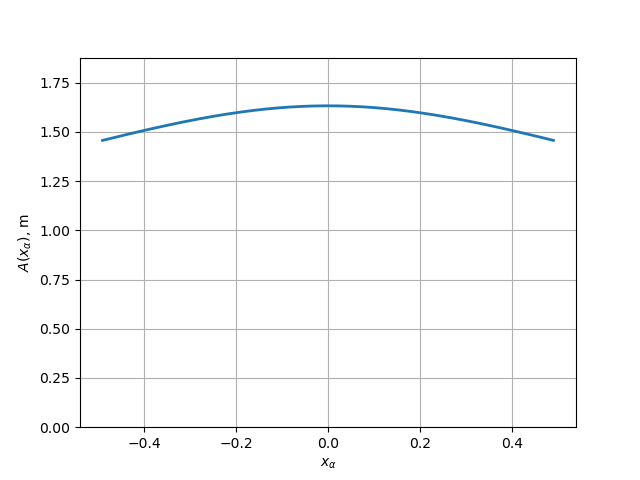

In [5]:
# Radius of gyration about the EA (in semichords): the largest physically valid |x_alpha|
r_theta = np.sqrt(params.I_ea / (params.m * b**2))
print(f"Radius of gyration about EA: r_theta = {r_theta:.4f} semichords")
print(f"Physically valid CG range:   |x_alpha| < {r_theta:.3f}\n")

# Sweep x_alpha across the valid range and record A(x_alpha)
xa_range = np.linspace(-0.49, 0.49, 300)
A_vals = np.zeros_like(xa_range)        # A(x_alpha)
for i, xa in enumerate(xa_range):
    p = TypicalSectionParams(x_alpha=xa)                 # same params, only x_alpha changes
    w, _ = calculate_coupled_frequencies_and_modes(p)    # undamped frequencies
    w2_sq = w[1]**2                                      # pitch-dominated frequency squared
    A_vals[i] = p.m * b * w2_sq / (p.m * w2_sq - p.k_h)  # A(x_alpha) from its definition

# Plot A vs x_alpha
fig, ax = plt.subplots()
ax.plot(xa_range, A_vals, lw=2)
ax.grid(True)
ax.set_xlabel(r'$x_\alpha$')
ax.set_ylabel(r'$A(x_\alpha)$, m')
ax.set_ylim(0, A_vals.max()*1.15)

# Calculate and print the variation in A across the range, relative to its value at the midpoint (x_alpha=0)
varA = (A_vals.max()-A_vals.min())/A_vals[len(xa_range)//2]*100
print(f"Variation in A relative to A(0): {varA:.1f}%")

Two observations:

1. **$A(x_\alpha) > 0$ everywhere** in the valid range. Hence the sign of the ratio $\phi_{2,h}/\phi_{2,\theta} = A x_\alpha$ is the sign of $x_\alpha$:
   - $x_\alpha > 0$ → ratio $> 0$ → heave and pitch components **in phase**;
   - $x_\alpha < 0$ → ratio $< 0$ → heave and pitch components **in anti-phase**.
2. $A$ appears to have a quadratic-like shape, with a maximum at $x_\alpha = 0$ and and a 11% variation across the range with respect to its value at the midpoint. This means that within the investigated range, $A$ is not constant, although the quadriatic variation appears to be relatively mild.

Let's now look at the ratio $\phi_{2,h}/\phi_{2,\theta}$ over the investigated range of $x_\alpha$.

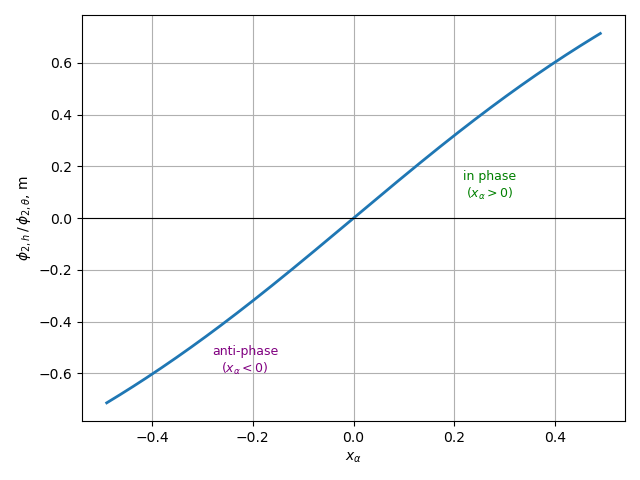

In [6]:
# Sweep x_alpha across the valid range and record the heave/pitch ratio
ratio_vals = np.zeros_like(xa_range)    # phi_{2,h}/phi_{2,theta}
for i, xa in enumerate(xa_range):
    p = TypicalSectionParams(x_alpha=xa)                 # same params, only x_alpha changes
    _, Ph = calculate_coupled_frequencies_and_modes(p)   # undamped modes
    ratio_vals[i] = Ph[0, 1] / Ph[1, 1]                  # phi_{2,h}/phi_{2,theta} from the eigenvector

# Plot the ratio vs x_alpha
fig, ax = plt.subplots()
ax.plot(xa_range, ratio_vals, lw=2)
ax.axhline(0, color='k', lw=0.8)
ax.grid(True)
ax.set_xlabel(r'$x_\alpha$'); ax.set_ylabel(r'$\phi_{2,h}\,/\,\phi_{2,\theta}$, m')
ax.text(0.75, 0.55, 'in phase\n($x_\\alpha>0$)', transform=ax.transAxes, fontsize=9, color='green', ha='center')
ax.text(0.3, 0.12, 'anti-phase\n($x_\\alpha<0$)', transform=ax.transAxes, fontsize=9, color='purple', ha='center')
plt.tight_layout()
plt.show()

Given the mild variation of $A$ with $x_\alpha$, the ratio $\phi_{2,h}/\phi_{2,\theta}$ is almost linear with $x_\alpha$.

### 2.2 Modal damping as a function of $x_\alpha$ and $e$

We assemble the stability condition from two ingredients derived above:

1. the modal damping of the pitch mode,
$$
c_2 = c_{l\alpha}\rho bV\;\phi_{2,h}\Big[\phi_{2,h} + b\big(\tfrac{1}{2}+e\big)\phi_{2,\theta}\Big];
$$
2. the mode-shape ratio, $\dfrac{\phi_{2,h}}{\phi_{2,\theta}} = A(x_\alpha)\,x_\alpha$.

Normalising the pitch component to $\phi_{2,\theta} = 1$ (the sign of $c_2$ is unaffected by scaling), the heave component becomes $\phi_{2,h} = A(x_\alpha)\,x_\alpha$. Substituting into $c_2$:

$$
\boxed{\;c_2 = c_{l\alpha}\rho bV\;A(x_\alpha)\,x_\alpha\Big[A(x_\alpha)\,x_\alpha + b\big(\tfrac{1}{2}+e\big)\Big]\;}
$$

The sign of $c_2$ is thus determined by the product:

$$
\sigma = x_\alpha\Big[A(x_\alpha)\,x_\alpha + b\big(\tfrac{1}{2}+e\big)\Big].
$$

This product is a function of both $x_\alpha$ and $e$, so the stability of the pitch-dominated mode at the onset of airspeed is governed by a two-dimensional stability map in the $(e, x_\alpha)$ plane, where the boundary between stable and unstable regions is given by the curve where $\sigma = 0$. We are now going to plot this stability map as a contour map and interpret it physically.

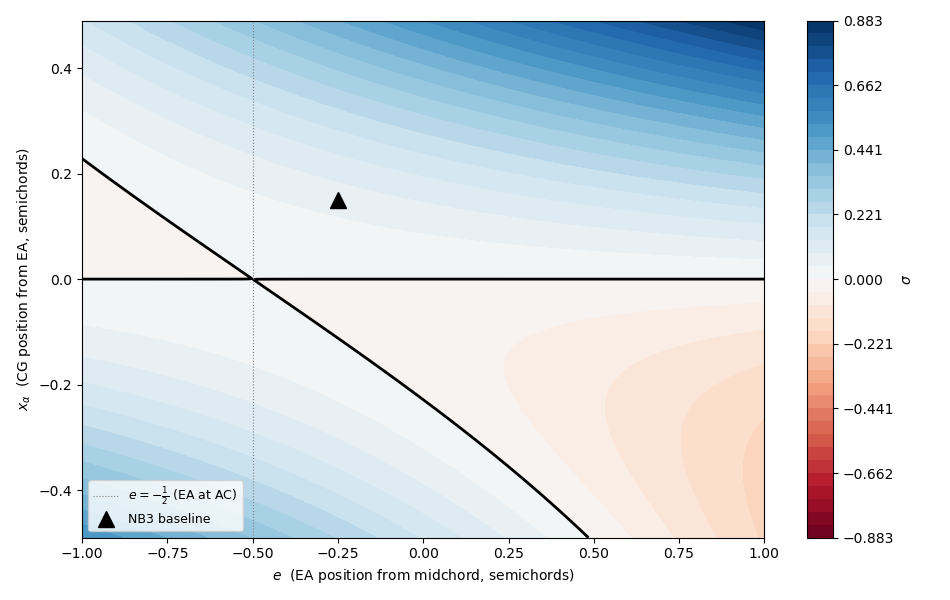

Red region: σ < 0 (pitch mode anti-damped, unstable at onset of airspeed).
Blue region: σ > 0 (pitch mode damped, stable at onset of airspeed).
Black line: σ = 0 stability boundary.


In [7]:
# We compute c_2 over a grid in (e, x_alpha). The pitch-mode shape depends ONLY on
# x_alpha (it comes from the structural M and K0, which do not involve e); the parameter
# e enters only through the moment arm b*(0.5+e) in the damping matrix. So we:
#   (1) precompute the pitch-mode components phi_{2,h}, phi_{2,theta} for each x_alpha,
#   (2) form c_2 on the (e, x_alpha) grid by broadcasting over e (cheap, vectorised).

e_vector = np.linspace(-1.0, 1.0, 400)        # EA position axis
xa_vector = np.linspace(-0.49, 0.49, 400)     # CG position axis (within the valid range)

# Calculate A for each x_alpha
A_vector = np.zeros_like(xa_vector)
phi2h = np.zeros_like(xa_vector)
phi2t = np.zeros_like(xa_vector)
for i, xa in enumerate(xa_vector):
    p = TypicalSectionParams(x_alpha=xa)                 # same params, only x_alpha changes
    w, _ = calculate_coupled_frequencies_and_modes(p)   # undamped freqs & modes
    w2_sq = w[1]**2                                      # pitch-dominated frequency squared
    A_vector[i] = p.m * b * w2_sq / (p.m * w2_sq - p.k_h)  # A(x_alpha) from its definition


# Build the 2D grids
e_array, xa_array = np.meshgrid(e_vector, xa_vector)
_, A_array = np.meshgrid(e_vector, A_vector)

# Calculate sigma
sigma = xa_array * (A_array * xa_array + b/2 * (0.5 + e_array))

# Plot the contour. Diverging colormap centred at zero: blue = damped (c2>0),
# red = anti-damped (c2<0); the thick black line is the c2 = 0 stability boundary.
fig, ax = plt.subplots(figsize=(9.5, 6))
vmax = np.nanmax(np.abs(sigma))
levels = np.linspace(-vmax, vmax, 41)
cf = ax.contourf(e_array, xa_array, sigma, levels=levels, cmap='RdBu', vmin=-vmax, vmax=vmax)
ax.contour(e_array, xa_array, sigma, levels=[0], colors='k', linewidths=2)   # stability boundary sigma = 0
cbar = fig.colorbar(cf, ax=ax); cbar.set_label(r'$\sigma$')

ax.axvline(-0.5, color='grey', lw=0.8, ls=':', label=r'$e=-\frac{1}{2}$ (EA at AC)')
ax.plot(params.e, params.x_alpha, 'k^', ms=11, zorder=5, label='NB3 baseline')
ax.set_xlabel(r'$e$  (EA position from midchord, semichords)')
ax.set_ylabel(r'$x_\alpha$  (CG position from EA, semichords)')
ax.set_xlim(-1.0, 1.0); ax.set_ylim(-0.49, 0.49)
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

print("Red region: σ < 0 (pitch mode anti-damped, unstable at onset of airspeed).")
print("Blue region: σ > 0 (pitch mode damped, stable at onset of airspeed).")
print("Black line: σ = 0 stability boundary.")

The map shows two black lines where $\sigma = 0$, which divide the plane into four regions, two stable and two unstable. As expected, one of the two lines is the horizontal line at $x_\alpha = 0$, which corresponds to the CG being on the EA. The other line is a curve describing where the term in square brackets is zero, i.e. where $A(x_\alpha)\,x_\alpha + b\big(\tfrac{1}{2}+e\big) = 0$. The two lines intersect at $e = -\frac{1}{2}$, which corresponds to the EA being at the mid-chord. The four regions can be described based on their position with respect to this intersection point:
- A first stable region is the one above the $x_\alpha = 0$ boundary and to the right of the other boundary. This is the region where our baseline configuration lies, as shown by the triangle marker.
- A second stable region is the one below the $x_\alpha = 0$ boundary and to the left of the other boundary.
- The two unstable regions are the ones below the $x_\alpha = 0$ boundary and to the right of the other boundary, and above the $x_\alpha = 0$ boundary and to the left of the other boundary.

An interesting observation can be made by drawing vertical lines at different values of $e$ and looking at the sign of $\sigma$ as we move along the line from positive to negative $x_\alpha$. For $e < -\frac{1}{2}$, the line crosses the first boundary for $x_\alpha > 0$, and the second boundary at $x_\alpha=0$, meaning that we go from stable to unstable and then back to stable. Also for $e > -\frac{1}{2}$ we go from stable to unstable and then back to stable, but this time the line crosses the $x_\alpha<0$ boundary first and the $x_\alpha=0$ boundary second. This means that, by following constant $e$ lines, the unstable region is always a finite strip between the two boundaries. For $e < -\frac{1}{2}$, the unstable strip occurs for $x_\alpha \geq 0$, while for $e > -\frac{1}{2}$ the unstable strip occurs for $x_\alpha \leq 0$. The case $e = -\frac{1}{2}$ is a special case where the two boundaries coincide, and the unstable strip collapse into a single point of neutral stability at $x_\alpha = 0$.

Following this reasoning, we are now going to compute the V-f and V-g curves at different values of $e$ and $x_\alpha$ to visualize how the stability at airspeed onset translates into the behaviour of the eigenvalues as $V$ increases.

## 3. Verification with Eigenvalue Sweeps

---

Let's pick three values of $e$ from the map:
- EA ahead of AC ($e=-0.7$);
- EA at AC ($e=-0.5$);
- EA behind AC ($e=-0.3$).

For each value of $e$, we choose $x_\alpha$ above, inside, and below the unstable strip. We then sweep $V \in [0.1, 200]$ m/s and track the eigenvalues. A damping ratio $\zeta$ of the pitch-dominated mode that starts negative (at the smallest $V$) confirms an initially unstable mode, exactly as the stability map predicts.

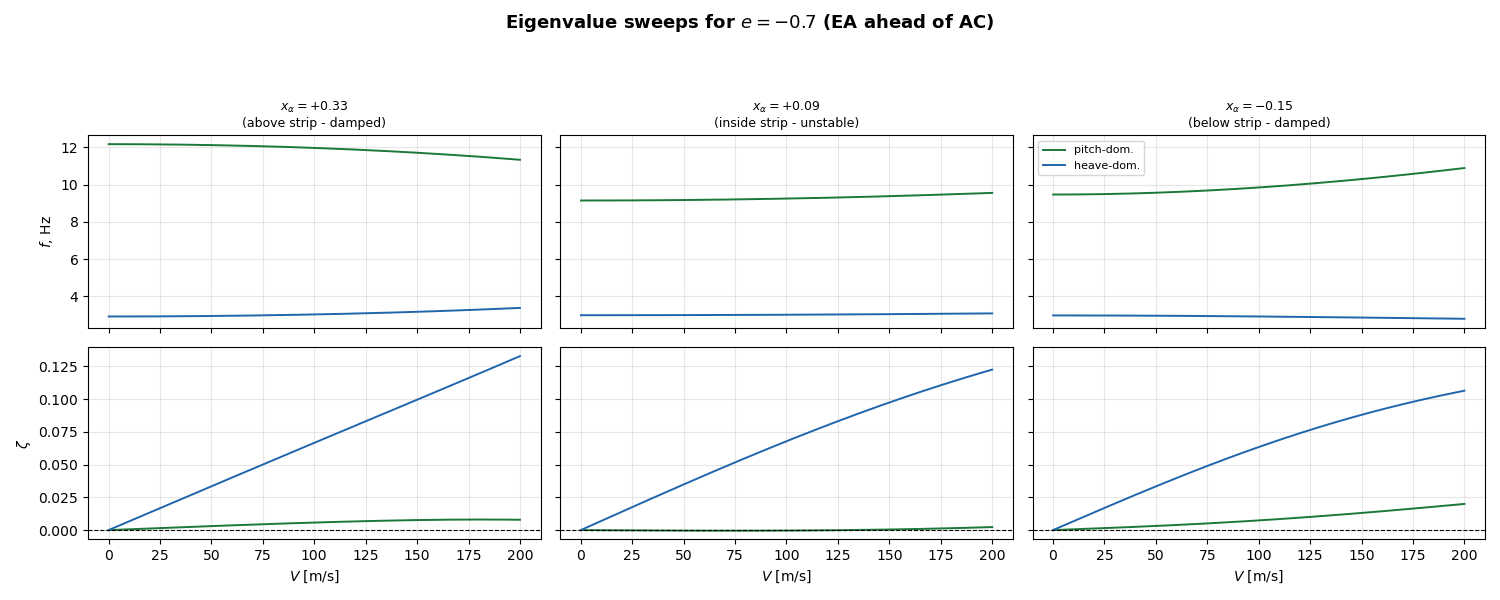

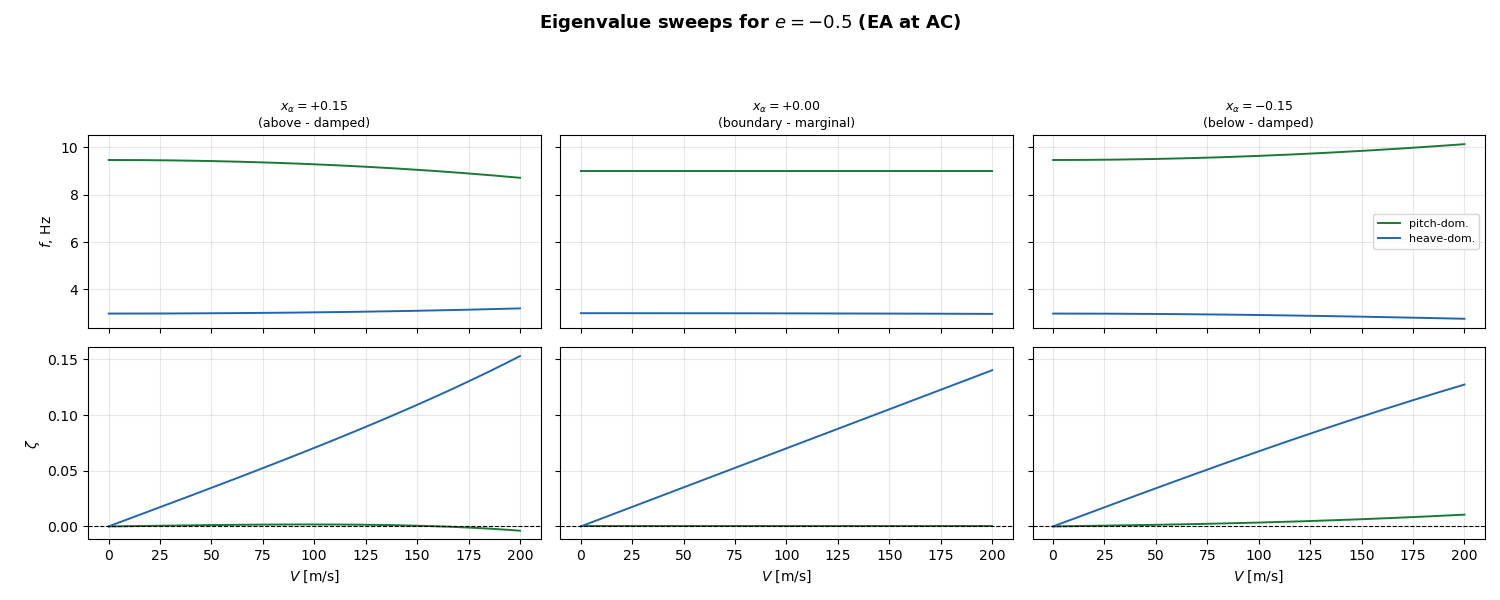

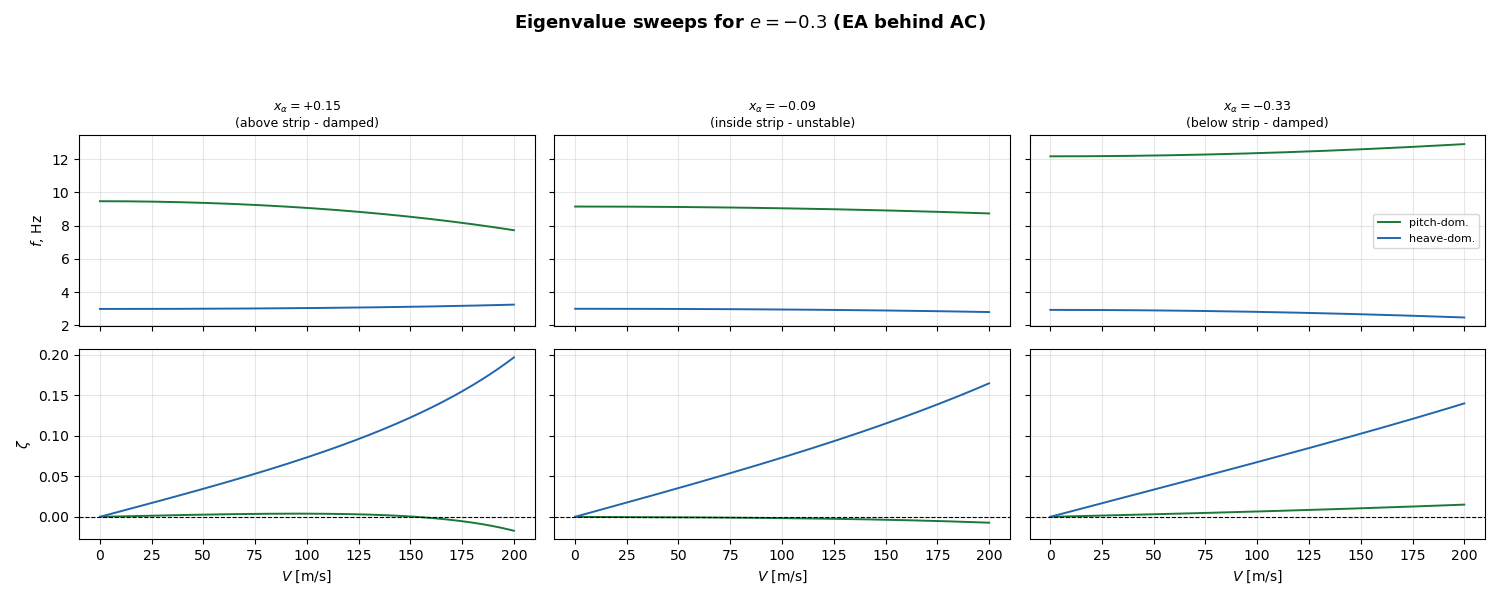

In [8]:
def eigenvalue_sweep(params, velocities, rho=1.225):
    "Track the 4 eigenvalues across a velocity sweep, matching modes by eigenvector continuity."
    n_v = len(velocities)
    tracked = np.zeros((n_v, 4), dtype=complex)
    prev = None                                          # previous step's eigenvectors
    for i, V in enumerate(velocities):
        evals, evecs = np.linalg.eig(build_system_matrix(params, V, rho))
        if prev is None:
            order = np.argsort(-evals.imag)              # first step: sort by frequency
        else:
            # Match each current eigenvector to the closest previous one (highest overlap)
            order = np.zeros(4, dtype=int); avail = list(range(4))
            for j in range(4):
                overlaps = [np.abs(np.dot(prev[:, j].conj(), evecs[:, k])) for k in avail]
                best = avail[np.argmax(overlaps)]; order[j] = best; avail.remove(best)
        tracked[i] = evals[order]; prev = evecs[:, order]
    return tracked

# A_0 = A(0): used only to pick representative x_alpha values relative to the strip
A0 = A_vals[len(xa_range)//2]

def strip_points(e_val):
    "Return three (x_alpha, label) pairs: above, inside, and below the unstable strip."
    x0 = -b*(0.5+e_val)/A0                               # approximate second root x_alpha_0
    if abs(x0) < 1e-6:                                   # e = -1/2: strip has zero width
        return [(0.15, 'above - damped'), (0.0, 'boundary - marginal'), (-0.15, 'below - damped')]
    if x0 > 0:                                           # strip on positive x_alpha side
        return [(min(x0+0.15, 0.45), 'above strip - damped'),
                (x0/2,               'inside strip - unstable'),
                (-0.15,              'below strip - damped')]
    else:                                                # strip on negative x_alpha side
        return [(0.15,               'above strip - damped'),
                (x0/2,               'inside strip - unstable'),
                (max(x0-0.15, -0.45),'below strip - damped')]

sweep_e = [(-0.7, 'EA ahead of AC'), (-0.5, 'EA at AC'), (-0.3, 'EA behind AC')]
velocities = np.linspace(0.1, 200, 800)                  # speed sweep [m/s]
COLORS = ['#1b7837', '#2166ac']                          # green=pitch, blue=heave
NAMES = ['pitch-dom.', 'heave-dom.']

# Iterate over the selected e values
for e_val, descr in sweep_e:
    # Create a 2x3 grid of subplots for this e value: top row = frequencies, bottom row = damping ratios;
    fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey='row')
    fig.suptitle(f'Eigenvalue sweeps for $e={e_val}$ ({descr})', fontsize=13, fontweight='bold')
    # Iterate over the three x_alpha values (above, inside, below the strip) for this e value
    for col, (xa, pos) in enumerate(strip_points(e_val)):
        # Compute the eigenvalue sweep for this (e, x_alpha) pair
        p = TypicalSectionParams(e=e_val, x_alpha=xa)
        eigs = eigenvalue_sweep(p, velocities)
        # Identify the two physical modes (those with significant imaginary part at low speed)
        # and plot their frequency and damping ratio vs velocity
        midx = [j for j in range(4) if eigs[0, j].imag > 0.1]   # the two physical modes
        for k, j in enumerate(midx[:2]):
            freq = np.abs(eigs[:, j].imag) / (2*np.pi)          # frequency [Hz]
            damp = -eigs[:, j].real / np.abs(eigs[:, j])        # damping ratio
            axes[0, col].plot(velocities, freq, color=COLORS[k], lw=1.4, label=NAMES[k])
            axes[1, col].plot(velocities, damp, color=COLORS[k], lw=1.4, label=NAMES[k])
        axes[0, col].set_title(f'$x_\\alpha={xa:+.2f}$\n({pos})', fontsize=9)
        axes[0, col].grid(True, alpha=0.3)
        if col == 2: axes[0, col].legend(fontsize=8)
        axes[1, col].axhline(0, color='k', lw=0.8, ls='--')     # zeta = 0 line
        axes[1, col].set_xlabel('$V$ [m/s]')
        axes[1, col].grid(True, alpha=0.3)

    # Set y-limits and labels for the first column only (shared y-axis)
    axes[0, 0].set_ylabel('$f$, Hz')
    axes[1, 0].set_ylabel(r'$\zeta$')

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

## 4. Physical Interpretation

---

### 4.1 Which aerodynamic force matters

At the onset of airspeed the modal damping $c_2$ governs the sign of the real part of the pitch-dominated mode's eigenvalue, and $c_2$ comes from the damping matrix $\boldsymbol{C}$, which scales with $V$. As we mentioned earlier, the aerodynamic *stiffness* scales with $V^2$, and consequently the static lift produced by the pitch angle $\theta$ is a higher-order effect compared to the the lift induced by the heave velocity $\dot{h}$ at small $V$. Therefore, for the physical explanation of the stability map at the onset of airspeed, **we consider only the lift generated by the heave velocity $\dot{h}$**, which is the single damping source of the model, and we deliberately ignore the static lift produced by the pitch angle $\theta$.

This heave-velocity-induced lift, $\Delta L = -c_{l\alpha}\rho b\,\dot{h}$, acts at the aerodynamic centre. It does two things: it acts directly on the heave DOF, and through the moment arm $b(\frac{1}{2}+e)$ from the AC to the EA it produces a pitching moment $\Delta M_\text{EA} = \Delta L\cdot b(\frac{1}{2}+e)$.

### 4.2 The two contributions to $c_2$

$$
c_2 = c_{l\alpha}\rho bV\Big[\;\underbrace{\phi_{2,h}^2}_{\text{(I) work on heave}} \;+\; \underbrace{b\big(\tfrac{1}{2}+e\big)\,\phi_{2,h}\phi_{2,\theta}}_{\text{(II) work on pitch via moment}}\;\Big].
$$

- **Term (I)** $\propto \phi_{2,h}^2 \geq 0$: the heave-induced lift always opposes the heave velocity, so this term always **removes** energy and is **always stabilising**.
- **Term (II)** $\propto b(\frac{1}{2}+e)\,\phi_{2,h}\phi_{2,\theta}$: its sign is $\text{sign}(\frac{1}{2}+e)\cdot\text{sign}(\phi_{2,h}\phi_{2,\theta})$. The product $\phi_{2,h}\phi_{2,\theta}$ is the **in-phase / anti-phase indicator**, whose sign equals the sign of $x_\alpha$ (Section 2.1).

Term (II) is **linear** in $\phi_{2,h}$ while term (I) is **quadratic**. This asymmetry is what produces the finite unstable strip that we see in the stability map.

### 4.3 Case $e > -\frac{1}{2}$ (EA behind AC): a strip of negative $x_\alpha$

Here the moment arm $b(\frac{1}{2}+e) > 0$. Take $x_\alpha < 0$: the pitch mode is in **anti-phase**, so a positive pitch goes with a negative heave. At the instant the mode passes through zero displacement at maximum velocity (so only the $\dot{h}$-induced lift acts, not the static-$\theta$ lift):

1. $\dot{\theta} > 0$ (nose-up rate) and, anti-phase, $\dot{h} < 0$ (EA moving down).
2. $\Delta L = -c_{l\alpha}\rho b\,\dot{h} > 0$ (downward heave raises the effective angle of attack → positive lift).
3. $\Delta M_\text{EA} = \Delta L\cdot b(\tfrac{1}{2}+e) > 0$ (nose-up moment).
4. $\Delta M_\text{EA}\cdot\dot{\theta} > 0$: the moment **reinforces** the pitch rate → energy fed into the mode.

This is term (II) acting destabilisingly. Meanwhile term (I) drains energy. The balance:

- **Near $x_\alpha = 0$**: $\phi_{2,h}\approx A x_\alpha$ is small, so the *linear* term (II) dominates the *quadratic* term (I) → **unstable**.
- **More negative $x_\alpha$**: $|\phi_{2,h}|$ is large, the quadratic term (I) overtakes the linear term (II) → **damped**.

Hence we have a **finite strip** from $x_\alpha = 0$ to a negative value where the two terms balance, which is the boundary of the unstable region.

### 4.4 Case $e < -\frac{1}{2}$ (EA ahead of AC): a strip of positive $x_\alpha$

Now the moment arm $b(\frac{1}{2}+e) < 0$. Take $x_\alpha > 0$: the pitch mode is **in phase**, a positive pitch goes with a positive heave. At maximum velocity:

1. $\dot{\theta} > 0$ (nose-up) and, in phase, $\dot{h} > 0$ (EA moving up).
2. $\Delta L = -c_{l\alpha}\rho b\,\dot{h} < 0$ (upward heave lowers the effective angle of attack → negative lift).
3. $\Delta M_\text{EA} = \underbrace{\Delta L}_{<0}\cdot\underbrace{b(\tfrac{1}{2}+e)}_{<0} > 0$ (nose-up moment).
4. $\Delta M_\text{EA}\cdot\dot{\theta} > 0$: again the moment **reinforces** the pitch rate → energy fed in.

The reversed moment arm (from $e$) is exactly compensated by the reversed heave direction (from $x_\alpha$), so the outcome is the same destabilising term (II). The same competition with the always-stabilising term (I) applies:

- **Near $x_\alpha = 0$**: small $\phi_{2,h}$, linear term (II) dominates → **unstable**.
- **Large positive $x_{\alpha}$**: large $\phi_{2,h}$, quadratic term (I) wins → **damped**.

Hence we have again a **finite strip** between $x_\alpha = 0$ and a positive value where the two terms balance, which is the boundary of the unstable region.

### 4.5 The special case $e = -\frac{1}{2}$

When the EA sits exactly at the aerodynamic centre, the moment arm is $b(\frac{1}{2}+e) = 0$, so term (II) simply vanishes, as the heave-induced lift acts right at the pivot and produces no pitching moment. Only the always-stabilising term (I) survives, so the pitch mode can never be unstable. There is only one point where $c_2 = 0$, which corresponds to $x_\alpha = 0$. In other words the strip closes to zero width, exactly as the stability map shows.

## 5. Caveat: This Is a Model Artifact

---

The pitch-mode instability for certain $(e, x_\alpha)$ is a genuine prediction of the **heave-velocity-only** quasi-steady model, but it is an artifact of having neglected the **pitch-rate** aerodynamic effects. In a fuller quasi-steady model the damping matrix gains a nonzero $(2,2)$ entry, meaning an aerodynamic moment proportional to $\dot{\theta}$.

**This model artifact is exactly what we are going to investigate in the next notebook.** There we study a typical section with a **pitch-only degree of freedom that includes the pitch-rate aerodynamic effects**, isolating the very term omitted here and showing its effect to the low-speed stability.

## Summary

---

At the onset of airspeed, the stability of the pitch-dominated mode is governed by the diagonal modal-damping projection $c_2 = \boldsymbol{\phi}_2^\top\boldsymbol{C}\boldsymbol{\phi}_2$. Substituting the mode-shape ratio $\phi_{2,h}/\phi_{2,\theta} = A(x_\alpha)x_\alpha$ (with $\phi_{2,\theta}=1$):

$$
c_2 \;==\; c_{l\alpha}\rho bV\Big[\underbrace{\phi_{2,h}^2}_{\text{always}\,\geq\,0} + \underbrace{b(\tfrac{1}{2}+e)\phi_{2,h}\phi_{2,\theta}}_{\text{sign}=\text{sign}[(\frac12+e)x_\alpha]}\Big].
\;
\; c_{l\alpha}\rho bV\;\underbrace{A x_\alpha}_{\phi_{2,h}}\Big[\underbrace{A x_\alpha}_{\phi_{2,h}} + b\big(\tfrac{1}{2}+e\big)\Big]
$$

The pitch-dominated mode is unstable in a **finite strip** between $x_\alpha=0$ and and either a positive or negative value of $x_\alpha$, depending on the parameter $e$, where the linear moment contribution overpowers the quadratic direct heave damping. The strip lies at negative $x_\alpha$ when $e>-\frac{1}{2}$ and at positive $x_\alpha$ when $e<-\frac{1}{2}$, closing at $e=-\frac{1}{2}$ (EA at AC). 